In [1]:
#!/usr/bin/env python
# coding: utf-8
# -*- coding: utf-8 -*-

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import random
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Activation
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

import csv

warnings.filterwarnings('ignore')

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
path = "/content/drive/MyDrive/trabalho-series-temporais/dados/dados.csv"

data = pd.read_csv(path,sep=',' )

#data = data.to_numpy()[0:-1,:]
data

,ano,mes,gasolina_comum_preco_revenda_avg
0,2001,7,1.6814
1,2001,8,1.7110
2,2001,9,1.7180
3,2001,10,1.7787
4,2001,11,1.7802
...,...,...,...
253,2022,9,5.0000
254,2022,10,4.8900
255,2022,11,5.0400
256,2022,12,4.9700


In [17]:
def discretizacao(data):
  #ano, mes, co2, y
  dataset = []
  # Iterate up to the second to last row to allow for data.iloc[i+1, ...]
  for i in range(len(data) - 1):
    v = []
    v.append(data.iloc[i, 0])   # 'ano' from current row
    v.append(data.iloc[i, 1])   # 'mes' from current row
    v.append(data.iloc[i, 2])   # 'gasolina_comum_preco_revenda_avg' from current row as 'gasolina'
    v.append(data.iloc[i + 1, 2]) # next 'gasolina_comum_preco_revenda_avg' as 'y'
    dataset.append(v)
  return pd.DataFrame(dataset, columns=["ano", "mes", "gasolina", "y"])

In [18]:
df = discretizacao(data)
df

,ano,mes,gasolina,y
0,2001,7,1.6814,1.7110
1,2001,8,1.7110,1.7180
2,2001,9,1.7180,1.7787
3,2001,10,1.7787,1.7802
4,2001,11,1.7802,1.7747
...,...,...,...,...
252,2022,8,5.3900,5.0000
253,2022,9,5.0000,4.8900
254,2022,10,4.8900,5.0400
255,2022,11,5.0400,4.9700


In [21]:
df["ano"] = df["ano"].astype('int')
df["mes"] = df["mes"].astype('int')
df["gasolina"] = df["gasolina"].astype('float')
df["y"] = df["y"].astype('float')

print(df.dtypes)

X, y = df.iloc[:, :3], df.iloc[:, 3]

x_train, x_test, y_train, y_test = train_test_split(X, y, train_size=0.9, random_state=0, shuffle=False)

scaler = MinMaxScaler(feature_range=(0, 1))
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, shuffle=False)

model = Sequential()

model.add(Dense(36, input_shape=(3,), activation='relu'))
model.add(Dense(18, activation="relu"))
model.add(Dense(8, activation="relu"))
model.add(Dense(1, activation='linear'))
model.compile(loss='mse', optimizer='adam', metrics=['mean_absolute_error', 'mse'])

batch_size = 2
epochs = 200

history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(x_val, y_val))

ano           int64
mes           int64
gasolina    float64
y           float64
co2         float64
dtype: object
Epoch 1/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 3.3051 - mean_absolute_error: 1.6309 - mse: 3.3051 - val_loss: 0.2837 - val_mean_absolute_error: 0.4507 - val_mse: 0.2837
Epoch 2/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0817 - mean_absolute_error: 0.2273 - mse: 0.0817 - val_loss: 0.1593 - val_mean_absolute_error: 0.3407 - val_mse: 0.1593
Epoch 3/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0442 - mean_absolute_error: 0.1682 - mse: 0.0442 - val_loss: 0.1026 - val_mean_absolute_error: 0.2727 - val_mse: 0.1026
Epoch 4/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0295 - mean_absolute_error: 0.1434 - mse: 0.0295 - val_loss: 0.1238 - val_mean_absolute_error: 0.3059 - val_mse: 0.1238
Epoch 5/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0219 - mean_absolute_error: 0.1259 - mse: 0.0219 - val_loss: 0.1190 - val_mean_absolute_error: 0.3027

In [22]:
y_pred = model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


In [23]:
auxDT=[]
for a in y_test:
    a1=[]
    a1.append(float(a))
    auxDT.append(a1)

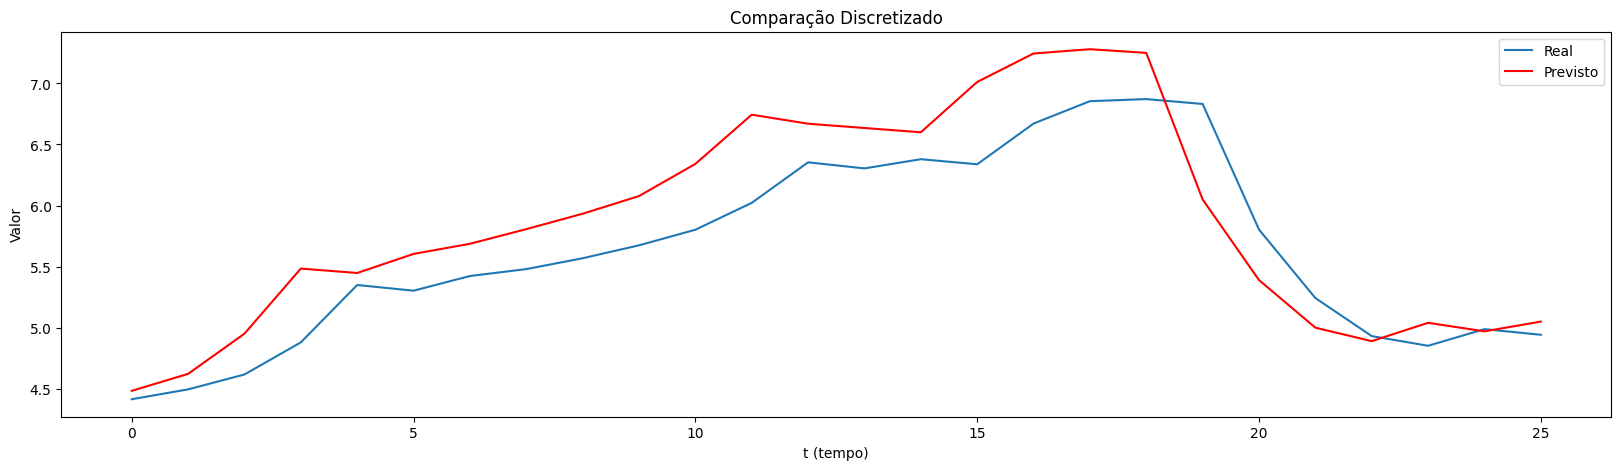

In [24]:
plt.figure(figsize=(20, 5))
plt.plot(y_pred, label="Real")
plt.plot(auxDT, color='red', label = 'Previsto')
plt.title('Comparação Discretizado')
plt.legend()
plt.xlabel("t (tempo)")
plt.ylabel('Valor')
plt.show()

In [34]:
def discretizacao_trig(data):
  #sen(mes), sen(ano), gasolina, y
  dataset = []
  # Iterate up to the second to last row to allow for data.iloc[i+1, ...]
  for i in range(len(data) - 1):
    v = []
    # Use .iloc for integer-location based indexing
    ano_val = data.iloc[i, 0]   # 'ano' from current row
    mes_val = data.iloc[i, 1]   # 'mes' from current row

    v.append(np.sin(int(mes_val))) # sin(mes)
    v.append(np.sin(int(ano_val))) # sin(ano)
    v.append(data.iloc[i, 2])     # 'gasolina_comum_preco_revenda_avg' from current row as 'gasolina'
    v.append(data.iloc[i + 1, 2]) # next 'gasolina_comum_preco_revenda_avg' as 'y'
    dataset.append(v)
  return pd.DataFrame(dataset, columns=["ano", "mes", "gasolina", "y"])

In [35]:
df_trig = discretizacao_trig(data)
df_trig

,ano,mes,gasolina,y
0,0.656987,0.193296,1.6814,1.7110
1,0.989358,0.193296,1.7110,1.7180
2,0.412118,0.193296,1.7180,1.7787
3,-0.544021,0.193296,1.7787,1.7802
4,-0.999990,0.193296,1.7802,1.7747
...,...,...,...,...
252,0.989358,-0.926751,5.3900,5.0000
253,0.412118,-0.926751,5.0000,4.8900
254,-0.544021,-0.926751,4.8900,5.0400
255,-0.999990,-0.926751,5.0400,4.9700


In [36]:
df_trig["ano"] = df_trig["ano"].astype('float')
df_trig["mes"] = df_trig["mes"].astype('float')
df_trig["gasolina"] = df_trig["gasolina"].astype('float')
df_trig["y"] = df_trig["y"].astype('float')

print(df_trig.dtypes)

X, y = df_trig.iloc[:, :3], df_trig.iloc[:, 3]

x_train, x_test, y_train, y_test = train_test_split(X, y, train_size=0.9, random_state=0, shuffle=False)

scaler = MinMaxScaler(feature_range=(0, 1))
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, shuffle=False)

model = Sequential()

model.add(Dense(36, input_shape=(3,), activation='relu'))
model.add(Dense(18, activation="relu"))
model.add(Dense(8, activation="relu"))
model.add(Dense(1, activation='linear'))
model.compile(loss='mse', optimizer='adam', metrics=['mean_absolute_error', 'mse'])

batch_size = 2
epochs = 200

history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(x_val, y_val))

ano         float64
mes         float64
gasolina    float64
y           float64
dtype: object
Epoch 1/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 3.4483 - mean_absolute_error: 1.6950 - mse: 3.4483 - val_loss: 1.0519 - val_mean_absolute_error: 0.9696 - val_mse: 1.0519
Epoch 2/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1861 - mean_absolute_error: 0.3451 - mse: 0.1861 - val_loss: 0.4592 - val_mean_absolute_error: 0.6396 - val_mse: 0.4592
Epoch 3/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0764 - mean_absolute_error: 0.2102 - mse: 0.0764 - val_loss: 0.2262 - val_mean_absolute_error: 0.4536 - val_mse: 0.2262
Epoch 4/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0302 - mean_absolute_error: 0.1247 - mse: 0.0302 - val_loss: 0.0564 - val_mean_absolute_error: 0.2122 - val_mse: 0.0564
Epoch 5/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0163 - mean_absolute_error: 0.0938 - mse: 0.0163 - val_loss: 0.0542 - val_mean_absolute_error: 0.2104 - val_mse: 0.0542
E

In [37]:
y_pred = model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


In [38]:
auxDT=[]
for a in y_test:
    a1=[]
    a1.append(float(a))
    auxDT.append(a1)

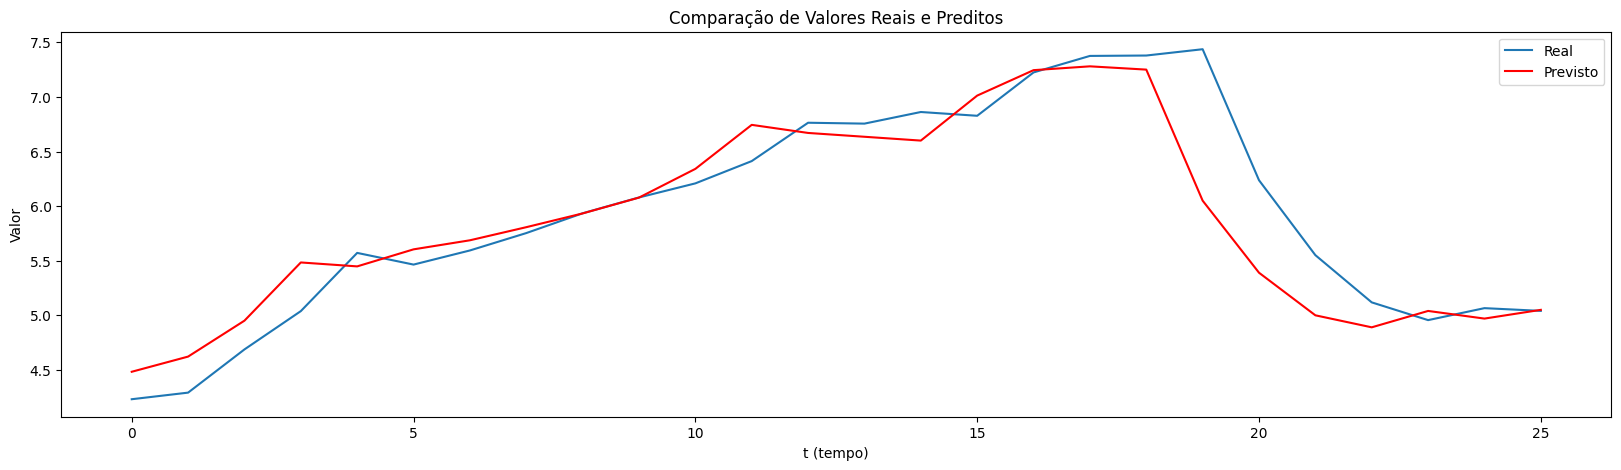

In [44]:
plt.figure(figsize=(20, 5))
plt.plot(y_pred, label="Real")
plt.plot(auxDT, color='red', label = 'Previsto')
plt.title('Comparação de Valores Reais e Preditos')
plt.legend()
plt.xlabel("t (tempo)")
plt.ylabel('Valor')
plt.show()

In [ ]:
def janelamento(data, janela):
  dataset = []
  tamanho_x = data.shape[0] - 1

  t=0
  while(t<tamanho_x - janela):
    y = 0
    row = []
    while(y < janela):
      if(y+t < tamanho_x):
        row.append(data[y+t,1])
      else:
        break
      y = y + 1

    row.append(data[y+t,1])

    dataset.append(row)

    t = t + 1


  dataset = pd.DataFrame(dataset)

  #df["co2"] = df["co2"].astype('float')

  dataset = dataset.astype(np.float)

  return pd.DataFrame(dataset)

In [ ]:
def janelamento(data, janela):
  dataset = []
  tamanho_x = data.shape[0] - 1

  t=0
  while(t<tamanho_x - janela):
    y = 0
    row = []
    while(y < janela):
      if(y+t < tamanho_x):
        row.append(data[y+t,1])
      else:
        break
      y = y + 1

    row.append(data[y+t,1])

    dataset.append(row)

    t = t + 1


  dataset = pd.DataFrame(dataset)

  #df["co2"] = df["co2"].astype('float')

  dataset = dataset.astype(float)

  return pd.DataFrame(dataset)

df_janela = janelamento(data, 6)
df_janela

,0,1,2,3,4,5,6
0,319.32,320.36,320.82,322.06,322.17,321.95,321.20
1,320.36,320.82,322.06,322.17,321.95,321.20,318.81
2,320.82,322.06,322.17,321.95,321.20,318.81,317.82
3,322.06,322.17,321.95,321.20,318.81,317.82,317.37
4,322.17,321.95,321.20,318.81,317.82,317.37,318.93
...,...,...,...,...,...,...,...
180,337.81,338.16,339.88,340.57,341.19,340.87,339.25
181,338.16,339.88,340.57,341.19,340.87,339.25,337.19
182,339.88,340.57,341.19,340.87,339.25,337.19,335.49
183,340.57,341.19,340.87,339.25,337.19,335.49,336.63


In [ ]:
print(df_janela.dtypes)

X, y = df_janela.iloc[:, :6], df_janela.iloc[:, 6]

x_train, x_test, y_train, y_test = train_test_split(X, y, train_size=0.9, random_state=0, shuffle=False)

scaler = MinMaxScaler(feature_range=(0, 1))
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, shuffle=False)

model = Sequential()

model.add(Dense(36, input_shape=(6,), activation='relu'))
model.add(Dense(18, activation="relu"))
model.add(Dense(8, activation="relu"))
model.add(Dense(1, activation='linear'))
model.compile(loss='mse', optimizer='adam', metrics=['mean_absolute_error', 'mse'])

batch_size = 2
epochs = 200

history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(x_val, y_val))

0    float64
1    float64
2    float64
3    float64
4    float64
5    float64
6    float64
dtype: object
Epoch 1/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 105570.3359 - mean_absolute_error: 324.8875 - mse: 105570.3359 - val_loss: 108671.3047 - val_mean_absolute_error: 329.6441 - val_mse: 108671.3047
Epoch 2/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 101232.8750 - mean_absolute_error: 318.1296 - mse: 101232.8750 - val_loss: 93071.8047 - val_mean_absolute_error: 305.0609 - val_mse: 93071.8047
Epoch 3/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 81529.7812 - mean_absolute_error: 284.6764 - mse: 81529.7812 - val_loss: 43046.1914 - val_mean_absolute_error: 207.2102 - val_mse: 43046.1914
Epoch 4/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 40570.8633 - mean_absolute_error: 192.6962 - mse: 40570.8633 - val_loss: 765.9158 - val_mean_absolute_error: 22.0064 - val_mse: 765.9158
Epoch 5/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12829.7207 - mean_absolute_erro

In [ ]:
y_pred = model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


In [ ]:
auxDT=[]
for a in y_test:
    a1=[]
    a1.append(float(a))
    auxDT.append(a1)

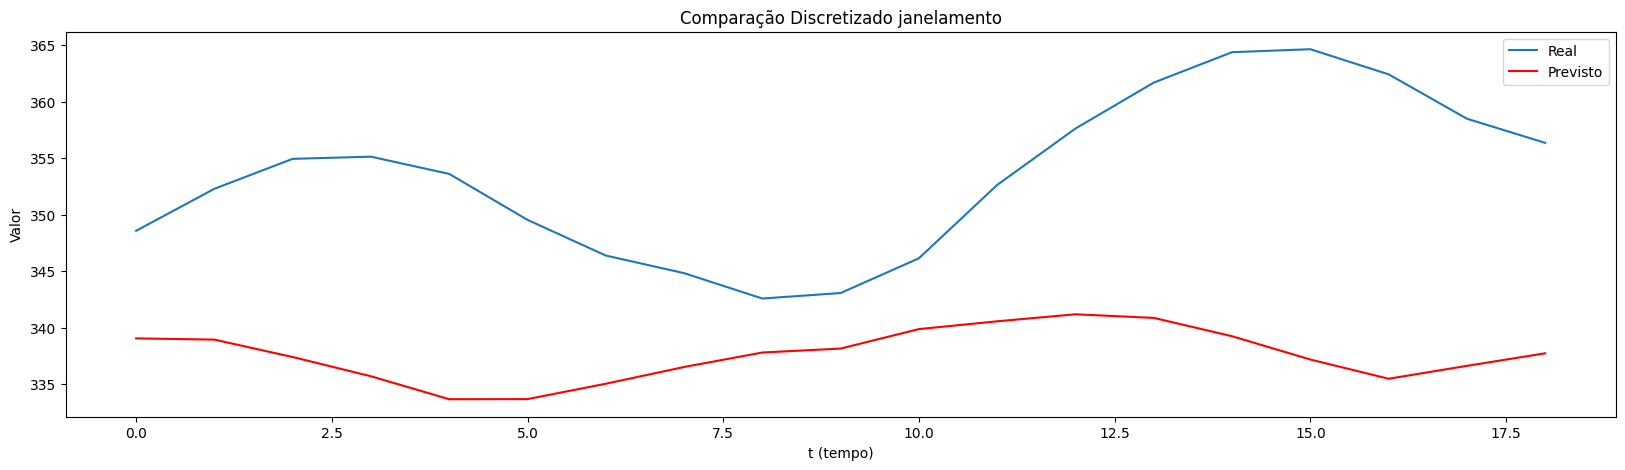

In [ ]:
plt.figure(figsize=(20, 5))
plt.plot(y_pred, label="Real")
plt.plot(auxDT, color='red', label = 'Previsto')
plt.title('Comparação Discretizado janelamento')
plt.legend()
plt.xlabel("t (tempo)")
plt.ylabel('Valor')
plt.show()